In [1]:
from pathlib import Path
import subprocess

REPO_URL = "https://github.com/seoultechpse/fenicsx-colab.git"
ROOT = Path("/content")
REPO_DIR = ROOT / "fenicsx-colab"

subprocess.run(["git", "clone", REPO_URL, str(REPO_DIR)], check=True)

USE_COMPLEX = False  # <--- Set True ONLY if you need complex PETSc
USE_CLEAN = False    # <--- Set True to remove existing environment

opts_str = " ".join(
  [o for c, o in [(USE_COMPLEX, "--complex"), (USE_CLEAN, "--clean")] if c]
)

get_ipython().run_line_magic("run", f"{REPO_DIR / 'setup_fenicsx.py'} {opts_str}")

🔧 FEniCSx Setup Configuration
PETSc type      : real
Clean install   : False

⚠️  Google Drive not mounted — using local cache (/content)

🔧 Installing FEniCSx environment...

🔍 Verifying PETSc type...
✅ Installed: Real PETSc (float64)

✨ Loading FEniCSx Jupyter magic... %%fenicsx registered

✅ FEniCSx setup complete!

Next steps:
  1. Run %%fenicsx --info to verify installation
  2. Use %%fenicsx in cells to run FEniCSx code
  3. Use -np N for parallel execution (e.g., %%fenicsx -np 4)

📌 Note: Real PETSc is installed
   - Recommended for most FEM problems
   - For complex problems, reinstall with --complex


---

# Heat(Ω₁) + Stokes(Ω₂) — Picard iteration  (DOLFINx 0.10)

**PDEs:**
- Ω₁: `-∇·(∇T) + u·∇T = 1`
- Ω₂: `-∇·(ν∇u) + ∇p = Ra·T·ê_y`,  `∇·u = 0`,  `ν(T)=ν₀·exp(-α·T)`

**Picard:** `update_coupling` → `solve_stokes` → `_transfer_u_to_heat` → `solve_heat`

**7 output figures:**
1. `convergence.png` — Picard residual (Ra=100)
2. `fields.png` — T, |u|+streamlines, p
3. `interface_profiles.png` — T(y), |u|(y), ν(y) at Γ
4. `ra_scan.png` — interface profiles Ra=100/200/500 with Nu in legend
5. `convergence_ra.png` — Picard convergence comparison across Ra
6. `overlay.png` — T+streamlines overlay (Ω₁+Ω₂ unified view)
7. `nusselt_vs_ra.png` — Nu vs Ra with scaling exponent β


In [2]:
%%fenicsx
# =============================================================================
# Heat (Ω₁) + Stokes (Ω₂) — Picard iteration  (DOLFINx 0.10.x)
#
# Ω₁ = [0.7,1]×[0,1]  : -∇·(∇T) = 1
# Ω₂ = [0,0.7]×[0,1]  : -∇·(ν∇u) + ∇p = Ra·T_s·ê_y,  ∇·u = 0
#
# Coupling  (Picard):
#   T from Ω₁ → sampled at interface → T_s on Ω₂
#   ν(T_s) = ν₀·exp(-α·T_s)
#   buoyancy = Ra·T_s·(0,1)  drives flow in Ω₂
#
# BCs:
#   Heat   : T=1 at x=0.7 (hot wall),  T=0 on right/top/bottom
#   Stokes : u=0 on left/top/bottom;   free outflow at x=0.7
# =============================================================================
import numpy as np
from pathlib import Path
import matplotlib; matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from mpi4py import MPI
from petsc4py import PETSc
import dolfinx.fem as fem
import dolfinx.fem.petsc as fem_petsc
import dolfinx.io as io
import dolfinx.mesh as dmesh
import basix.ufl, ufl
from dolfinx.geometry import (bb_tree, compute_collisions_points,
                                compute_colliding_cells)

comm   = MPI.COMM_WORLD
outdir = Path("results"); outdir.mkdir(exist_ok=True)

# ── Parameters ────────────────────────────────────────────────────────────────
N        = 80
IFACE    = 0.7
NU0      = 1.0
ALPHA    = 0.5
RA       = 100.0
T_HOT    = 1.0
T_COLD   = 0.0
MAX_ITER = 30
TOL      = 1e-7

# ── Meshes ────────────────────────────────────────────────────────────────────
parent = dmesh.create_unit_square(comm, N, N)
tdim   = parent.topology.dim
parent.topology.create_connectivity(tdim, 0)
c2v   = parent.topology.connectivity(tdim, 0)
xg    = parent.geometry.x
cells = np.arange(parent.topology.index_map(tdim).size_local, dtype=np.int32)
cx    = np.array([xg[c2v.links(c), 0].mean() for c in cells])

heat_mesh,   *_ = dmesh.create_submesh(parent, tdim, cells[cx >= IFACE])
stokes_mesh, *_ = dmesh.create_submesh(parent, tdim, cells[cx <  IFACE])
print(f"Parent mesh : {parent.topology.index_map(tdim).size_global} cells")
print(f"Heat   mesh : {heat_mesh.topology.index_map(tdim).size_global} cells")
print(f"Stokes mesh : {stokes_mesh.topology.index_map(tdim).size_global} cells")

# ── Function spaces ────────────────────────────────────────────────────────────
T_fs  = fem.functionspace(heat_mesh,   basix.ufl.element("Lagrange", "triangle", 1))
V_fs  = fem.functionspace(stokes_mesh, basix.ufl.element("Lagrange", "triangle", 2, shape=(2,)))
Q_fs  = fem.functionspace(stokes_mesh, basix.ufl.element("Lagrange", "triangle", 1))
DG0_s = fem.functionspace(stokes_mesh, basix.ufl.element("DG",       "triangle", 0))

# ── Solution functions ─────────────────────────────────────────────────────────
Th = fem.Function(T_fs,  name="Temperature")
uh = fem.Function(V_fs,  name="Velocity")
ph = fem.Function(Q_fs,  name="Pressure")
nu = fem.Function(DG0_s, name="Viscosity");   nu.x.array[:] = NU0
Ts = fem.Function(DG0_s, name="T_on_stokes"); Ts.x.array[:] = 0.0

# velocity interpolated onto heat mesh for convection term u·∇T
DG0_h  = fem.functionspace(heat_mesh, basix.ufl.element("DG", "triangle", 0, shape=(2,)))
uh_on_heat = fem.Function(DG0_h, name="u_on_heat"); uh_on_heat.x.array[:] = 0.0

# local-only DOF counts (no ghosts)
n_T = T_fs.dofmap.index_map.size_local * T_fs.dofmap.index_map_bs
n_u = V_fs.dofmap.index_map.size_local * V_fs.dofmap.index_map_bs
n_p = Q_fs.dofmap.index_map.size_local * Q_fs.dofmap.index_map_bs

# ── Boundary conditions ────────────────────────────────────────────────────────
def _hbc(fn, val):
    return fem.dirichletbc(PETSc.ScalarType(val),
                           fem.locate_dofs_geometrical(T_fs, fn), T_fs)
bcs_heat = [
    _hbc(lambda x: np.isclose(x[0], IFACE), T_HOT),
    _hbc(lambda x: np.isclose(x[0], 1.0),  T_COLD),
    _hbc(lambda x: np.isclose(x[1], 1.0),  T_COLD),
    _hbc(lambda x: np.isclose(x[1], 0.0),  T_COLD),
]

def _noslip(fn):
    return fem.dirichletbc(np.zeros(2, dtype=PETSc.ScalarType),
                           fem.locate_dofs_geometrical(V_fs, fn), V_fs)
bcs_stokes = [
    _noslip(lambda x: np.isclose(x[0], 0.0)),
    _noslip(lambda x: np.isclose(x[1], 1.0)),
    _noslip(lambda x: np.isclose(x[1], 0.0)),
]

# ── Heat variational form — rebuilt each Picard step (uh_on_heat changes) ─────
# -∇·(∇T) + u·∇T = 1
# Re-compiled inside solve_heat() so updated uh_on_heat is picked up.
t, s = ufl.TrialFunction(T_fs), ufl.TestFunction(T_fs)
dx_h = ufl.dx(domain=heat_mesh)

def solve_heat():
    """Assemble and solve heat equation with current convection uh_on_heat."""
    a_T = (ufl.inner(ufl.grad(t), ufl.grad(s))
           + ufl.inner(uh_on_heat, ufl.grad(t)) * s) * dx_h
    L_T = fem.Constant(heat_mesh, PETSc.ScalarType(1.0)) * s * dx_h
    fem_petsc.LinearProblem(
        a_T, L_T, u=Th, bcs=bcs_heat,
        petsc_options_prefix="heat_",
        petsc_options={"ksp_type": "preonly", "pc_type": "lu",
                       "pc_factor_mat_solver_type": "mumps"},
    ).solve()

# ── Stokes trial/test functions (used inside solve_stokes each call) ───────────
u_tr, v_te = ufl.TrialFunction(V_fs), ufl.TestFunction(V_fs)
p_tr, q_te = ufl.TrialFunction(Q_fs), ufl.TestFunction(Q_fs)
dx_s = ufl.dx(domain=stokes_mesh)

# Fixed blocks (independent of nu and Ts)
a_up_form = fem.form(-p_tr * ufl.div(v_te) * dx_s)
a_pu_form = fem.form( ufl.div(u_tr) * q_te * dx_s)
L_p_form  = fem.form(fem.Constant(stokes_mesh, PETSc.ScalarType(0.0)) * q_te * dx_s)

# ── Helper ─────────────────────────────────────────────────────────────────────
def _to_csr(A):
    ai, aj, av = A.getValuesCSR()
    return sp.csr_matrix((av, aj, ai))

# ── Stokes solver ──────────────────────────────────────────────────────────────
def solve_stokes():
    """
    Recompile a_uu and L_u each call so that the current values of
    nu and Ts are picked up (DOLFINx caches coefficient values at
    form-compilation time, so we must re-form every iteration).
    """
    # re-compile both nu-dependent and Ts-dependent forms
    a_uu_f = fem.form(nu   * ufl.inner(ufl.grad(u_tr), ufl.grad(v_te)) * dx_s)
    L_u_f  = fem.form(RA   * Ts * v_te[1] * dx_s)   # buoyancy: Ra·T·ê_y

    Auu = fem_petsc.assemble_matrix(a_uu_f, bcs=bcs_stokes); Auu.assemble()
    Aup = fem_petsc.assemble_matrix(a_up_form, bcs=[]);       Aup.assemble()
    Apu = fem_petsc.assemble_matrix(a_pu_form, bcs=[]);       Apu.assemble()
    bu  = fem_petsc.assemble_vector(L_u_f)
    bp  = fem_petsc.assemble_vector(L_p_form)

    fem_petsc.apply_lifting(bu, [a_uu_f], bcs=[bcs_stokes])
    bu.ghostUpdate(addv=PETSc.InsertMode.ADD, mode=PETSc.ScatterMode.REVERSE)
    fem_petsc.set_bc(bu, bcs_stokes)
    bp.ghostUpdate(addv=PETSc.InsertMode.ADD, mode=PETSc.ScatterMode.REVERSE)

    # sanity: print RHS norm on first call
    if not hasattr(solve_stokes, "_called"):
        solve_stokes._called = True
        print(f"  [Stokes] ‖bu‖ = {np.linalg.norm(bu.array[:n_u]):.3e}"
              f"  (>0 ↔ buoyancy active)")

    S = sp.bmat([[_to_csr(Auu), _to_csr(Aup)],
                 [_to_csr(Apu), None]], format="csr")
    rhs = np.concatenate([bu.array[:n_u], bp.array[:n_p]])

    # pin last pressure DOF → remove null-space
    S = S.tolil(); S[-1,:] = 0.0; S[-1,-1] = 1.0; rhs[-1] = 0.0
    S = S.tocsr()

    sol = spla.spsolve(S, rhs)
    uh.x.array[:n_u] = sol[:n_u]
    ph.x.array[:n_p] = sol[n_u:]
    uh.x.scatter_forward(); ph.x.scatter_forward()

    for obj in (Auu, Aup, Apu, bu, bp): obj.destroy()

# ── Coupling update ─────────────────────────────────────────────────────────────
def update_coupling():
    """
    Ω₁ → Ω₂: sample Th at IFACE+ε → update nu (viscosity) and Ts (buoyancy field).
    Called at start of each Picard step with T^k.
    """
    n_sc = (stokes_mesh.topology.index_map(tdim).size_local
            + stokes_mesh.topology.index_map(tdim).num_ghosts)
    stokes_mesh.topology.create_connectivity(tdim, 0)
    sc2v     = stokes_mesh.topology.connectivity(tdim, 0)
    xg_s     = stokes_mesh.geometry.x
    c_stokes = np.array([xg_s[sc2v.links(c)].mean(axis=0) for c in range(n_sc)])

    snap_h   = np.full(n_sc, IFACE + 0.5/N)   # just inside Ω₁ (heat side)
    pts_h    = np.column_stack([snap_h, c_stokes[:, 1], np.zeros(n_sc)])
    hbb      = bb_tree(heat_mesh, heat_mesh.topology.dim)
    cols_h   = compute_collisions_points(hbb, pts_h)
    cells_hh = compute_colliding_cells(heat_mesh, cols_h, pts_h)

    T_vals = np.zeros(n_sc)
    for i in range(n_sc):
        c = cells_hh.links(i)
        if len(c):
            T_vals[i] = Th.eval(pts_h[i:i+1], np.array([c[0]])).flat[0]

    nu.x.array[:n_sc] = NU0 * np.exp(-ALPHA * T_vals)
    Ts.x.array[:n_sc] = T_vals
    nu.x.scatter_forward(); Ts.x.scatter_forward()


def _transfer_u_to_heat():
    """
    Ω₂ → Ω₁: sample uh at IFACE-ε → update uh_on_heat (convection velocity for heat eq).
    Called AFTER solve_stokes() so T^{k+1} sees u^{k+1}.
    """
    n_hc = (heat_mesh.topology.index_map(tdim).size_local
            + heat_mesh.topology.index_map(tdim).num_ghosts)
    heat_mesh.topology.create_connectivity(tdim, 0)
    hc2v   = heat_mesh.topology.connectivity(tdim, 0)
    xg_h   = heat_mesh.geometry.x
    c_heat = np.array([xg_h[hc2v.links(c)].mean(axis=0) for c in range(n_hc)])

    snap_s   = np.full(n_hc, IFACE - 0.5/N)   # just inside Ω₂ (Stokes side)
    pts_s    = np.column_stack([snap_s, c_heat[:, 1], np.zeros(n_hc)])
    sbb      = bb_tree(stokes_mesh, stokes_mesh.topology.dim)
    cols_s   = compute_collisions_points(sbb, pts_s)
    cells_ss = compute_colliding_cells(stokes_mesh, cols_s, pts_s)

    u_vals = np.zeros((n_hc, 2))
    for i in range(n_hc):
        c = cells_ss.links(i)
        if len(c):
            u_vals[i] = uh.eval(pts_s[i:i+1], np.array([c[0]])).flatten()[:2]

    # DG-0 vector DOFs interleaved: [ux_0, uy_0, ux_1, uy_1, ...]
    uh_on_heat.x.array[0::2] = u_vals[:, 0]
    uh_on_heat.x.array[1::2] = u_vals[:, 1]
    uh_on_heat.x.scatter_forward()


# ── Picard iteration ───────────────────────────────────────────────────────────
print(f"\n{'='*55}")
print(f"  Picard:  ν(T)=ν₀·exp(-α·T),  Ra={RA}")
print(f"  ν₀={NU0}, α={ALPHA}, tol={TOL:.0e}, max_iter={MAX_ITER}")
print(f"{'='*55}")

# Step 0: get initial T with pure diffusion (uh_on_heat=0 → no convection yet)
solve_heat()
print(f"  T^0: [{Th.x.array[:n_T].min():.3f}, {Th.x.array[:n_T].max():.3f}]")

history = []
for it in range(MAX_ITER):
    T_old = Th.x.array[:n_T].copy()         # save T^k

    update_coupling()                        # Ω₁→Ω₂: ν,Ts ← T^k
    solve_stokes()                           # u^{k+1}, p^{k+1}
    # now transfer u^{k+1} → heat mesh so solve_heat uses the latest velocity
    _transfer_u_to_heat()                    # Ω₂→Ω₁: uh_on_heat ← u^{k+1}
    solve_heat()                             # T^{k+1}  (advection-diffusion with u^{k+1})

    T_new  = Th.x.array[:n_T]
    T_norm = max(np.linalg.norm(T_old), 1e-12)
    diff   = np.linalg.norm(T_new - T_old) / T_norm
    history.append(diff)
    print(f"  iter {it+1:3d} :  ‖ΔT‖/‖T‖ = {diff:.3e}"
          f"  |u|_max={np.abs(uh.x.array[:n_u]).max():.3e}")

    if diff < TOL:
        print(f"\n  ✓  Converged in {it+1} iter  (residual={diff:.2e})")
        break
else:
    print(f"\n  ✗  Did not converge in {MAX_ITER} iterations")

# ── XDMF output ───────────────────────────────────────────────────────────────
V_p1  = fem.functionspace(stokes_mesh,
                           basix.ufl.element("Lagrange", "triangle", 1, shape=(2,)))
u_out = fem.Function(V_p1, name="Velocity_P1"); u_out.interpolate(uh)
print("\nWriting XDMF …")
for fn_sol, mesh_, fname in [
    (Th,    heat_mesh,   "temperature"),
    (u_out, stokes_mesh, "velocity"),
    (ph,    stokes_mesh, "pressure"),
]:
    with io.XDMFFile(comm, str(outdir/f"{fname}.xdmf"), "w") as xf:
        xf.write_mesh(mesh_); xf.write_function(fn_sol)
    print(f"  → results/{fname}.xdmf")

# ── Plot helpers ───────────────────────────────────────────────────────────────
def _geo_tri(mesh_):
    td = mesh_.topology.dim
    mesh_.topology.create_connectivity(td, 0)
    c2v_ = mesh_.topology.connectivity(td, 0)
    nc   = mesh_.topology.index_map(td).size_local
    tris = np.array([c2v_.links(c) for c in range(nc)], dtype=np.int32)
    xg_  = mesh_.geometry.x
    return mtri.Triangulation(xg_[:,0], xg_[:,1], tris)

def _eval_s(fn, mesh_, bt=None):
    xg_  = mesh_.geometry.x
    pts  = np.column_stack([xg_[:,:2], np.zeros(len(xg_))])
    bt_  = bt or bb_tree(mesh_, mesh_.topology.dim)
    col  = compute_collisions_points(bt_, pts)
    cel  = compute_colliding_cells(mesh_, col, pts)
    out  = np.zeros(len(xg_))
    for i in range(len(xg_)):
        c = cel.links(i)
        if len(c): out[i] = fn.eval(pts[i:i+1], np.array([c[0]])).flat[0]
    return out

def _eval_mag(fn, mesh_, bt=None):
    xg_  = mesh_.geometry.x
    pts  = np.column_stack([xg_[:,:2], np.zeros(len(xg_))])
    bt_  = bt or bb_tree(mesh_, mesh_.topology.dim)
    col  = compute_collisions_points(bt_, pts)
    cel  = compute_colliding_cells(mesh_, col, pts)
    out  = np.zeros(len(xg_))
    for i in range(len(xg_)):
        c = cel.links(i)
        if len(c): out[i] = np.linalg.norm(fn.eval(pts[i:i+1], np.array([c[0]])).flatten())
    return out

bt_s = bb_tree(stokes_mesh, stokes_mesh.topology.dim)

# ── Figure 1: convergence ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
if history and min(history) > 0:
    ax.semilogy(range(1, len(history)+1), history, "o-", lw=2, ms=5, color="steelblue")
    ax.axhline(TOL, color="crimson", ls="--", label=f"tol={TOL:.0e}"); ax.legend()
elif history:
    ax.plot(range(1, len(history)+1), history, "o-", lw=2, ms=5, color="steelblue")
ax.set_xlabel("Picard iteration"); ax.set_ylabel(r"$\|\Delta T\|/\|T\|$")
ax.set_title("Picard Convergence"); ax.grid(True, alpha=0.4)
fig.tight_layout(); fig.savefig(outdir/"convergence.png", dpi=150); plt.close(fig)
print("\nSaved results/convergence.png")

# ── Figure 2: fields ───────────────────────────────────────────────────────────
tri_h = _geo_tri(heat_mesh)
tri_s = _geo_tri(stokes_mesh)
T_n   = _eval_s(Th, heat_mesh)
u_n   = _eval_mag(uh, stokes_mesh, bt_s)
p_n   = _eval_s(ph, stokes_mesh, bt_s)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
ax = axes[0]
cf = ax.tricontourf(tri_h, T_n, levels=30, cmap="hot")
ax.triplot(tri_h, lw=0.1, color="k", alpha=0.15)
fig.colorbar(cf, ax=ax, label="T")
ax.axvline(IFACE, color="cyan", lw=1.5, ls="--", label="Γ")
ax.set_title("Temperature  T"); ax.set_aspect("equal")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.legend(fontsize=8)

ax = axes[1]
cf = ax.tricontourf(tri_s, u_n, levels=30, cmap="viridis")
ax.triplot(tri_s, lw=0.1, color="k", alpha=0.12)
fig.colorbar(cf, ax=ax, label="|u|")
Ng = 22
xi_g = np.linspace(0.01, IFACE-0.01, Ng); yi_g = np.linspace(0.01, 0.99, Ng)
Xi, Yi = np.meshgrid(xi_g, yi_g)
pts_g  = np.column_stack([Xi.ravel(), Yi.ravel(), np.zeros(Ng*Ng)])
col_g  = compute_collisions_points(bt_s, pts_g)
cel_g  = compute_colliding_cells(stokes_mesh, col_g, pts_g)
Ux = np.zeros(Ng*Ng); Uy = np.zeros(Ng*Ng)
for i in range(Ng*Ng):
    c = cel_g.links(i)
    if len(c):
        v_ = uh.eval(pts_g[i:i+1], np.array([c[0]])).flatten()
        Ux[i] = v_[0]; Uy[i] = v_[1]
ax.streamplot(xi_g, yi_g, Ux.reshape(Ng,Ng), Uy.reshape(Ng,Ng),
              density=1.0, color="white", linewidth=0.8, arrowsize=0.7)
ax.set_title("Velocity  |u| + streamlines"); ax.set_aspect("equal")
ax.set_xlabel("x"); ax.set_ylabel("y")

ax = axes[2]
cf = ax.tricontourf(tri_s, p_n, levels=30, cmap="RdBu_r")
ax.triplot(tri_s, lw=0.1, color="k", alpha=0.12)
fig.colorbar(cf, ax=ax, label="p")
ax.set_title("Pressure  p"); ax.set_aspect("equal")
ax.set_xlabel("x"); ax.set_ylabel("y")

fig.suptitle(f"Heat(Ω₁)+Stokes(Ω₂),  Ra={RA},  ν(T)={NU0}·exp(-{ALPHA}·T),  "
             f"Picard: {len(history)} iters", fontsize=11)
fig.tight_layout(); fig.savefig(outdir/"fields.png", dpi=150); plt.close(fig)
print("Saved results/fields.png")

# ── Figure 3: interface profiles  (T evaluated from Th, not hardcoded) ────────
Np     = 80
y_ln   = np.linspace(0.02, 0.98, Np)

# --- T at interface: sample Th just inside Ω₁ (heat side) ---
x_h_ep  = IFACE + 1.5/N
bt_h    = bb_tree(heat_mesh, heat_mesh.topology.dim)
pts_th  = np.column_stack([np.full(Np, x_h_ep), y_ln, np.zeros(Np)])
col_th  = compute_collisions_points(bt_h, pts_th)
cel_th  = compute_colliding_cells(heat_mesh, col_th, pts_th)
T_ln    = np.zeros(Np)
for i in range(Np):
    c = cel_th.links(i)
    if len(c): T_ln[i] = Th.eval(pts_th[i:i+1], np.array([c[0]])).flat[0]

# --- |u| at interface: sample uh just inside Ω₂ (Stokes side) ---
x_s_ep  = IFACE - 1.5/N
pts_if  = np.column_stack([np.full(Np, x_s_ep), y_ln, np.zeros(Np)])
col_if  = compute_collisions_points(bt_s, pts_if)
cel_if  = compute_colliding_cells(stokes_mesh, col_if, pts_if)
u_ln    = np.zeros(Np)
for i in range(Np):
    c = cel_if.links(i)
    if len(c): u_ln[i] = np.linalg.norm(uh.eval(pts_if[i:i+1], np.array([c[0]])).flatten())

nu_ln = NU0 * np.exp(-ALPHA * T_ln)

fig2, axes2 = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
axes2[0].plot(T_ln,  y_ln, "r-", lw=2); axes2[0].set_xlabel("T"); axes2[0].set_ylabel("y")
axes2[0].set_title("T at Γ  (from Th)"); axes2[0].grid(alpha=0.4)
axes2[1].plot(u_ln,  y_ln, "b-", lw=2); axes2[1].set_xlabel("|u|")
axes2[1].set_title(f"|u| near Γ (x={IFACE:.1f}−ε)"); axes2[1].grid(alpha=0.4)
axes2[2].plot(nu_ln, y_ln, "g-", lw=2); axes2[2].set_xlabel("ν(T)")
axes2[2].set_title("ν(T) at Γ"); axes2[2].grid(alpha=0.4)
fig2.suptitle(f"Interface Profiles at x={IFACE:.1f}  (Ra={RA})", fontsize=12)
fig2.tight_layout(); fig2.savefig(outdir/"interface_profiles.png", dpi=150); plt.close(fig2)
print("Saved results/interface_profiles.png")

# ── Ra scan: solve for each Ra, collect all data ──────────────────────────────
print("\nRunning Ra scan (Ra = 100, 200, 500) …")

RA_LIST = [100.0, 200.0, 500.0]
COLORS  = ["steelblue", "darkorange", "crimson"]

def _nusselt(mesh_, fn_T, iface_x, eps, n_pts=200):
    """
    Nusselt number at x = iface_x:
        Nu = -∫₀¹ (∂T/∂x)|_{x=iface_x⁺} dy

    One-sided forward difference entirely inside Ω₁ (x > iface_x):
        ∂T/∂x ≈ (T(x+2ε) − T(x+ε)) / ε

    Since T decreases away from the hot interface, ∂T/∂x < 0 → Nu > 0.
    """
    y_nu  = np.linspace(0.01, 0.99, n_pts)
    bt_h_ = bb_tree(mesh_, mesh_.topology.dim)

    def _sample(x_smp):
        pts_ = np.column_stack([np.full(n_pts, x_smp), y_nu, np.zeros(n_pts)])
        col_ = compute_collisions_points(bt_h_, pts_)
        cel_ = compute_colliding_cells(mesh_, col_, pts_)
        v_   = np.zeros(n_pts)
        for i in range(n_pts):
            c_ = cel_.links(i)
            if len(c_): v_[i] = fn_T.eval(pts_[i:i+1], np.array([c_[0]])).flat[0]
        return v_

    # both sample points inside Ω₁ (heat domain, x > IFACE)
    T_near = _sample(iface_x + eps)       # just inside heat domain
    T_far  = _sample(iface_x + 2 * eps)   # further inside heat domain
    dTdx   = (T_far - T_near) / eps       # ∂T/∂x < 0 (T drops away from hot wall)
    return -np.trapezoid(dTdx, y_nu)      # Nu > 0


def _solve_stokes_ra(rv):
    """Same as solve_stokes() but with explicit Rayleigh number rv."""
    a_uu_f = fem.form(nu * ufl.inner(ufl.grad(u_tr), ufl.grad(v_te)) * dx_s)
    L_u_f  = fem.form(float(rv) * Ts * v_te[1] * dx_s)
    Auu = fem_petsc.assemble_matrix(a_uu_f, bcs=bcs_stokes); Auu.assemble()
    Aup = fem_petsc.assemble_matrix(a_up_form, bcs=[]);       Aup.assemble()
    Apu = fem_petsc.assemble_matrix(a_pu_form, bcs=[]);       Apu.assemble()
    bu  = fem_petsc.assemble_vector(L_u_f)
    bp  = fem_petsc.assemble_vector(L_p_form)
    fem_petsc.apply_lifting(bu, [a_uu_f], bcs=[bcs_stokes])
    bu.ghostUpdate(addv=PETSc.InsertMode.ADD, mode=PETSc.ScatterMode.REVERSE)
    fem_petsc.set_bc(bu, bcs_stokes)
    bp.ghostUpdate(addv=PETSc.InsertMode.ADD, mode=PETSc.ScatterMode.REVERSE)
    S   = sp.bmat([[_to_csr(Auu), _to_csr(Aup)],
                   [_to_csr(Apu), None]], format="csr")
    rhs = np.concatenate([bu.array[:n_u], bp.array[:n_p]])
    S   = S.tolil(); S[-1,:]=0; S[-1,-1]=1; rhs[-1]=0; S=S.tocsr()
    sol = spla.spsolve(S, rhs)
    uh.x.array[:n_u] = sol[:n_u]; ph.x.array[:n_p] = sol[n_u:]
    uh.x.scatter_forward(); ph.x.scatter_forward()
    for obj in (Auu, Aup, Apu, bu, bp): obj.destroy()


# {Ra: (T_arr, u_arr, nu_arr, hist, n_iters, Nu, T_field, u_field, p_field)}
ra_results = {}

for ra_val in RA_LIST:
    print(f"  Ra={ra_val:.0f} …", end=" ", flush=True)

    # reset all fields
    for fn_ in (Th, uh, ph, nu, Ts, uh_on_heat):
        fn_.x.array[:] = 0.0; fn_.x.scatter_forward()
    nu.x.array[:] = NU0; nu.x.scatter_forward()

    solve_heat()

    hist_ra = []
    for it in range(MAX_ITER):
        T_old_ra = Th.x.array[:n_T].copy()
        update_coupling()
        _solve_stokes_ra(ra_val)
        _transfer_u_to_heat()
        solve_heat()
        diff_ra = np.linalg.norm(Th.x.array[:n_T]-T_old_ra) / max(np.linalg.norm(T_old_ra), 1e-12)
        hist_ra.append(diff_ra)
        if diff_ra < TOL: break

    n_iters = len(hist_ra)
    umax    = np.abs(uh.x.array[:n_u]).max()

    # Nusselt number
    nu_eps = 1.5 / N
    Nu_val = _nusselt(heat_mesh, Th, IFACE, nu_eps)

    print(f"converged in {n_iters} iters,  |u|_max={umax:.3e},  Nu={Nu_val:.4f}")

    # interface profiles
    T_ra = np.zeros(Np)
    for i in range(Np):
        c = cel_th.links(i)
        if len(c): T_ra[i] = Th.eval(pts_th[i:i+1], np.array([c[0]])).flat[0]
    u_ra = np.zeros(Np)
    for i in range(Np):
        c = cel_if.links(i)
        if len(c): u_ra[i] = np.linalg.norm(uh.eval(pts_if[i:i+1], np.array([c[0]])).flatten())
    nu_ra = NU0 * np.exp(-ALPHA * T_ra)

    # field snapshots for overlay figure
    T_snap  = _eval_s(Th,  heat_mesh)
    u_snap  = _eval_mag(uh, stokes_mesh, bt_s)
    Ux_snap = np.zeros(Ng*Ng); Uy_snap = np.zeros(Ng*Ng)
    for i in range(Ng*Ng):
        c = cel_g.links(i)
        if len(c):
            v_ = uh.eval(pts_g[i:i+1], np.array([c[0]])).flatten()
            Ux_snap[i] = v_[0]; Uy_snap[i] = v_[1]

    ra_results[ra_val] = dict(T=T_ra, u=u_ra, nu=nu_ra, hist=hist_ra,
                               n=n_iters, Nu=Nu_val,
                               T_snap=T_snap, u_snap=u_snap,
                               Ux=Ux_snap, Uy=Uy_snap)

# restore fields to original Ra
if RA_LIST[-1] != RA:
    for fn_ in (Th, uh, ph, nu, Ts, uh_on_heat):
        fn_.x.array[:] = 0.0; fn_.x.scatter_forward()
    nu.x.array[:] = NU0; nu.x.scatter_forward()
    solve_heat()
    for _ in range(MAX_ITER):
        T_old_ = Th.x.array[:n_T].copy()
        update_coupling(); solve_stokes(); _transfer_u_to_heat(); solve_heat()
        if np.linalg.norm(Th.x.array[:n_T]-T_old_)/max(np.linalg.norm(T_old_),1e-12) < TOL:
            break

# ── Figure 4: Ra scan — interface profiles ────────────────────────────────────
fig4, axes4 = plt.subplots(1, 3, figsize=(14, 5), sharey=True)
for ra_val, col in zip(RA_LIST, COLORS):
    d   = ra_results[ra_val]
    lbl = f"Ra={ra_val:.0f}  ({d['n']} iters,  Nu={d['Nu']:.3f})"
    axes4[0].plot(d["T"],  y_ln, "-", lw=2, color=col, label=lbl)
    axes4[1].plot(d["u"],  y_ln, "-", lw=2, color=col, label=lbl)
    axes4[2].plot(d["nu"], y_ln, "-", lw=2, color=col, label=lbl)
for ax_, xl_, ttl_ in zip(axes4, ["T", "|u|", "ν(T)"],
                            ["T at Γ  (from Th)",
                             f"|u| near Γ (x={IFACE:.1f}−ε)",
                             "ν(T) at Γ"]):
    ax_.set_xlabel(xl_); ax_.grid(alpha=0.4); ax_.set_title(ttl_);
axes4[0].legend(fontsize=7)
axes4[0].set_ylabel("y")
fig4.suptitle(f"Ra scan: interface profiles at x={IFACE:.1f}  [ν₀={NU0}, α={ALPHA}]", fontsize=12)
fig4.tight_layout(); fig4.savefig(outdir/"ra_scan.png", dpi=150); plt.close(fig4)
print("Saved results/ra_scan.png")

# ── Figure 5: Picard convergence comparison across Ra ─────────────────────────
fig5, ax5 = plt.subplots(figsize=(7, 4))
for ra_val, col in zip(RA_LIST, COLORS):
    d    = ra_results[ra_val]
    hist = d["hist"]
    if hist and min(hist) > 0:
        ax5.semilogy(range(1, len(hist)+1), hist, "o-", lw=2, ms=5,
                     color=col, label=f"Ra={ra_val:.0f}  ({d['n']} iters)")
ax5.axhline(TOL, color="k", ls="--", lw=1, label=f"tol={TOL:.0e}")
ax5.set_xlabel("Picard iteration"); ax5.set_ylabel(r"$\|\Delta T\|/\|T\|$")
ax5.set_title("Picard Convergence  —  Ra comparison"); ax5.grid(True, which="both", alpha=0.4)
ax5.legend(fontsize=9)
fig5.tight_layout(); fig5.savefig(outdir/"convergence_ra.png", dpi=150); plt.close(fig5)
print("Saved results/convergence_ra.png")

# ── Figure 6: T + streamlines overlay (Heat Ω₁ + Stokes Ω₂ in one view) ──────

# --- global min/max for consistent scaling ---
T_all = np.hstack([ra_results[ra]["T_snap"] for ra in RA_LIST])
u_all = np.hstack([ra_results[ra]["u_snap"] for ra in RA_LIST])

Tmin, Tmax = T_all.min(), T_all.max()
umin, umax = u_all.min(), u_all.max()

fig6, axes6 = plt.subplots(
    1, len(RA_LIST),
    figsize=(5 * len(RA_LIST), 5),
    constrained_layout=True
)

for ax6, ra_val in zip(axes6, RA_LIST):
    d = ra_results[ra_val]

    # --- Temperature in Ω₁ ---
    cfT = ax6.tricontourf(
        tri_h, d["T_snap"],
        levels=20, cmap="hot",
        vmin=Tmin, vmax=Tmax,
        alpha=0.9
    )
    ax6.tricontour(
        tri_h, d["T_snap"],
        levels=8, colors="w",
        linewidths=0.5, alpha=0.5
    )

    # --- |u| in Ω₂ ---
    cfU = ax6.tricontourf(
        tri_s, d["u_snap"],
        levels=20, cmap="Blues",
        vmin=umin, vmax=umax,
        alpha=0.55
    )

    # --- Streamlines ---
    try:
        ax6.streamplot(
            xi_g, yi_g,
            d["Ux"].reshape(Ng, Ng),
            d["Uy"].reshape(Ng, Ng),
            density=0.9,
            color="white",
            linewidth=0.7,
            arrowsize=0.6
        )
    except Exception:
        pass

    # --- Interface ---
    ax6.axvline(IFACE, color="cyan", lw=2, ls="--")

    ax6.set_title(f"Ra={ra_val:.0f}  (Nu={d['Nu']:.3f})", fontsize=10)
    ax6.set_aspect("equal")
    ax6.set_xlim(0, 1)
    ax6.set_ylim(0, 1)
    ax6.set_xlabel("x")

axes6[0].set_ylabel("y")

cbar_T = fig6.colorbar(
    cfT,
    ax=axes6,
    location="left",
    fraction=0.035,
    pad=0.08
)
cbar_T.set_label("Temperature T")

cbar_u = fig6.colorbar(
    cfU,
    ax=axes6,
    location="bottom",
    orientation="horizontal",
    fraction=0.05,
    pad=0.12
)
cbar_u.set_label("Velocity magnitude |u|")

fig6.suptitle(
    f"T (Ω₁) + |u| / streamlines (Ω₂) overlay  [ν₀={NU0}, α={ALPHA}]",
    fontsize=12
)

fig6.savefig(outdir / "overlay.png", dpi=150)
plt.close(fig6)

print("Saved results/overlay.png")


# ── Figure 7: Nusselt number vs Ra ────────────────────────────────────────────
ra_arr = np.array(RA_LIST)
nu_arr = np.array([ra_results[rv]["Nu"] for rv in RA_LIST])

fig7, ax7 = plt.subplots(figsize=(6, 4))
ax7.plot(ra_arr, nu_arr, "o-", lw=2, ms=8, color="darkgreen")
for rv, nv, col in zip(ra_arr, nu_arr, COLORS):
    ax7.annotate(f"Nu={nv:.3f}", xy=(rv, nv),
                 xytext=(rv, nv + 0.05*(nu_arr.max()-nu_arr.min())),
                 ha="center", fontsize=9, color=col)
ax7.set_xlabel("Ra  (Rayleigh number)"); ax7.set_ylabel("Nu  (Nusselt number)")
ax7.set_title("Nusselt Number vs Rayleigh Number\n"
              r"$Nu = -\int_0^1 \partial T/\partial x\,|_\Gamma\, dy$")
ax7.grid(alpha=0.4); ax7.set_xticks(ra_arr)

# log-log fit for scaling exponent (only if all Nu > 0)
if len(ra_arr) >= 2 and np.all(nu_arr > 0):
    log_fit = np.polyfit(np.log(ra_arr), np.log(nu_arr), 1)
    beta    = log_fit[0]
    ra_fit  = np.linspace(ra_arr.min()*0.9, ra_arr.max()*1.1, 100)
    nu_fit  = np.exp(log_fit[1]) * ra_fit**beta
    ax7.plot(ra_fit, nu_fit, "--", color="gray", lw=1.2,
             label=f"fit: Nu ∝ Ra$^{{{beta:.3f}}}$")
    ax7.legend(fontsize=9)
elif not np.all(nu_arr > 0):
    ax7.text(0.5, 0.5, "Nu값 확인 필요 (음수 존재)",
             transform=ax7.transAxes, ha="center", color="red")

fig7.tight_layout(); fig7.savefig(outdir/"nusselt_vs_ra.png", dpi=150); plt.close(fig7)
print("Saved results/nusselt_vs_ra.png")

# ── Summary ────────────────────────────────────────────────────────────────────
print(f"\n{'='*55}")
u_mag  = np.linalg.norm(uh.x.array[:n_u].reshape(-1,2), axis=1)
nu_rng = NU0 * np.exp(-ALPHA * np.array([Th.x.array[:n_T].max(),
                                          Th.x.array[:n_T].min()]))
print(f"  T   : [{Th.x.array[:n_T].min():.4f}, {Th.x.array[:n_T].max():.4f}]")
print(f"  |u| :  mean={u_mag.mean():.4e}   max={u_mag.max():.4e}")
print(f"  p   : [{ph.x.array[:n_p].min():.4f}, {ph.x.array[:n_p].max():.4f}]")
print(f"  ν   : [{nu_rng[0]:.4f}, {nu_rng[1]:.4f}]")
print(f"  Ts  : [{Ts.x.array.min():.4f}, {Ts.x.array.max():.4f}]")
print(f"  Picard iterations : {len(history)}")
print(f"{'='*55}")


Parent mesh : 12800 cells
Heat   mesh : 3840 cells
Stokes mesh : 8960 cells

  Picard:  ν(T)=ν₀·exp(-α·T),  Ra=100.0
  ν₀=1.0, α=0.5, tol=1e-07, max_iter=30
  T^0: [0.000, 1.000]
  [Stokes] ‖bu‖ = 5.745e-01  (>0 ↔ buoyancy active)
  iter   1 :  ‖ΔT‖/‖T‖ = 1.318e-01  |u|_max=4.814e+00
  iter   2 :  ‖ΔT‖/‖T‖ = 7.822e-04  |u|_max=4.812e+00
  iter   3 :  ‖ΔT‖/‖T‖ = 4.067e-06  |u|_max=4.812e+00
  iter   4 :  ‖ΔT‖/‖T‖ = 3.415e-08  |u|_max=4.812e+00

  ✓  Converged in 4 iter  (residual=3.41e-08)

Writing XDMF …
  → results/temperature.xdmf
  → results/velocity.xdmf
  → results/pressure.xdmf

Saved results/convergence.png
Saved results/fields.png
Saved results/interface_profiles.png

Running Ra scan (Ra = 100, 200, 500) …
  Ra=100 … converged in 4 iters,  |u|_max=4.812e+00,  Nu=4.9443
  Ra=200 … converged in 5 iters,  |u|_max=9.595e+00,  Nu=5.4108
  Ra=500 … converged in 6 iters,  |u|_max=2.349e+01,  Nu=7.0777
Saved results/ra_scan.png
Saved results/convergence_ra.png
Saved results/overlay.png

--- convergence ---


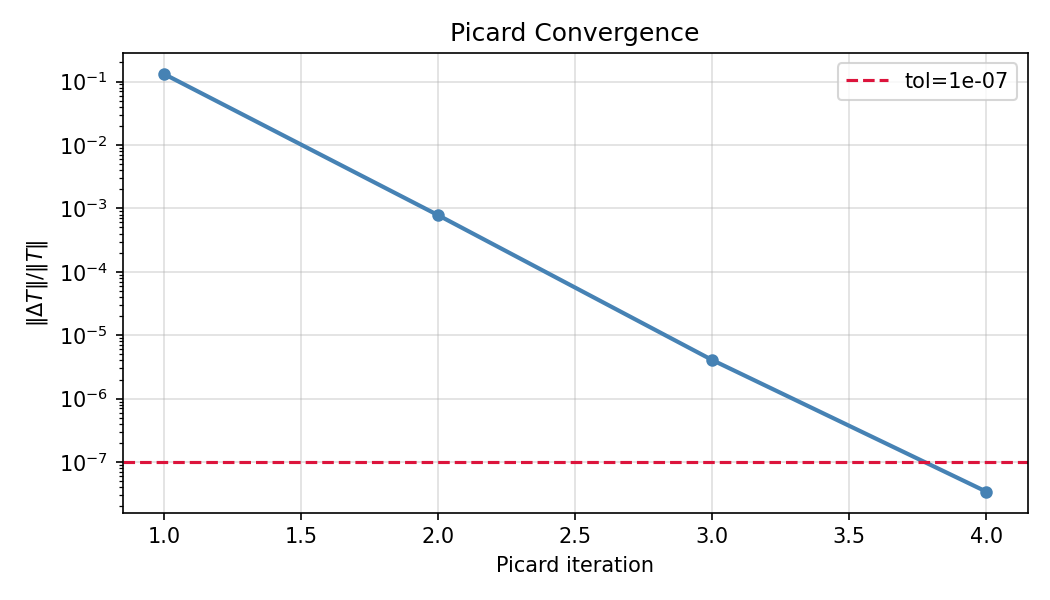

--- fields ---


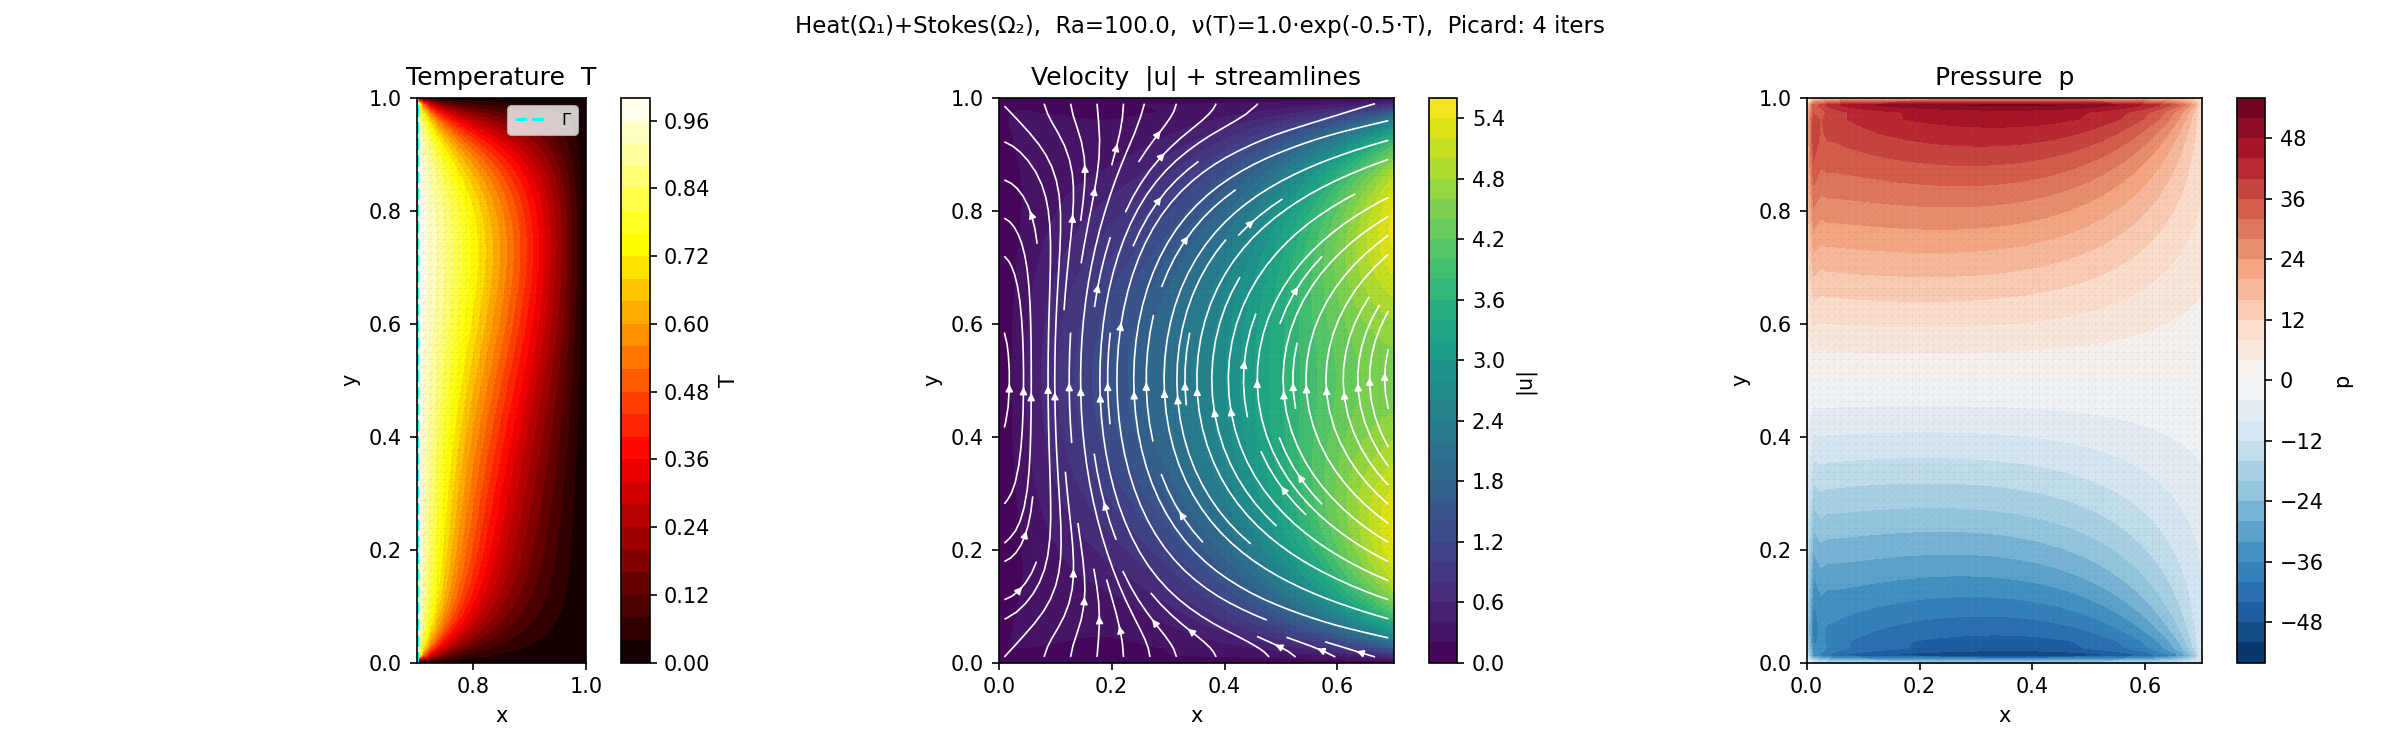

--- interface_profiles ---


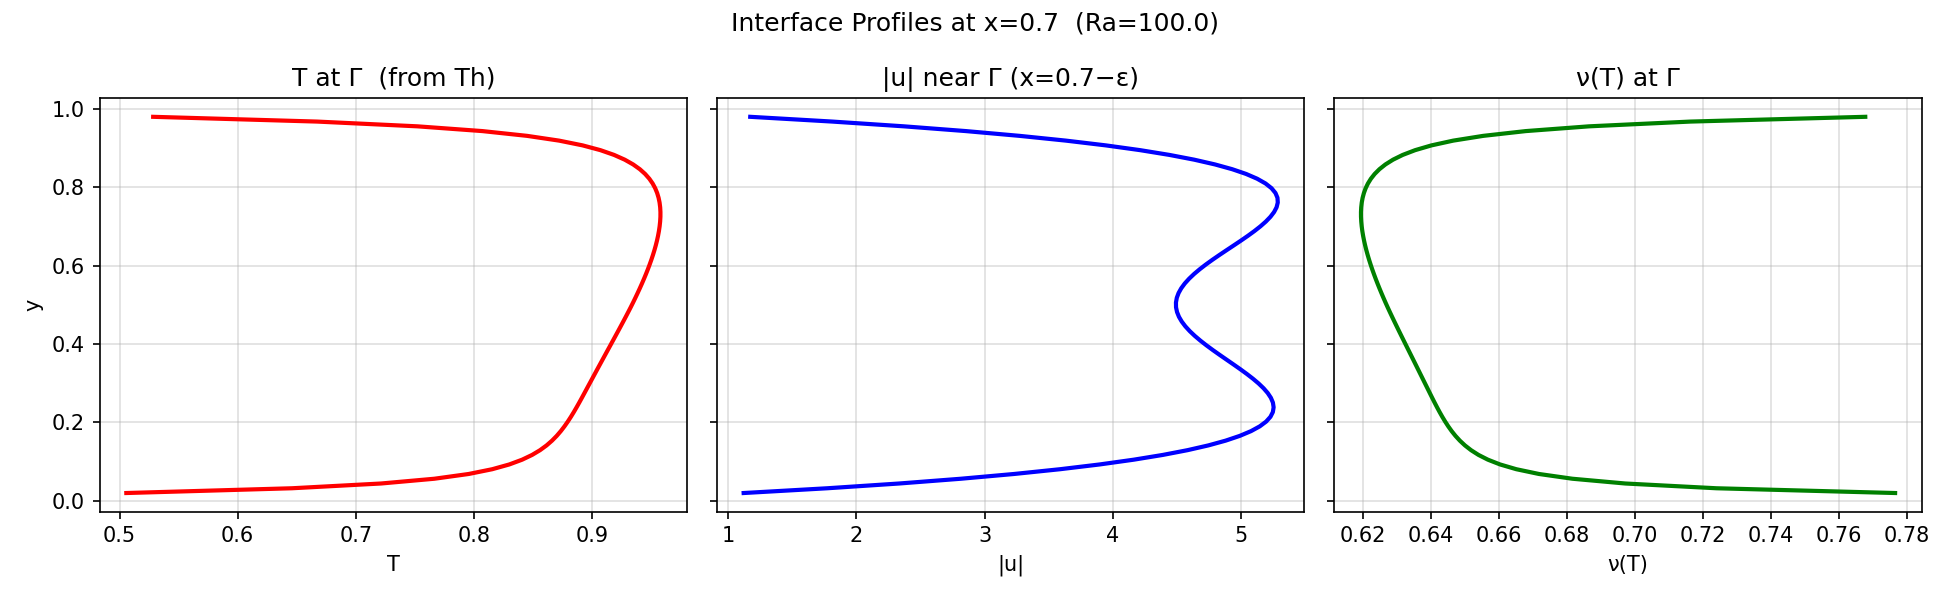

--- ra_scan ---


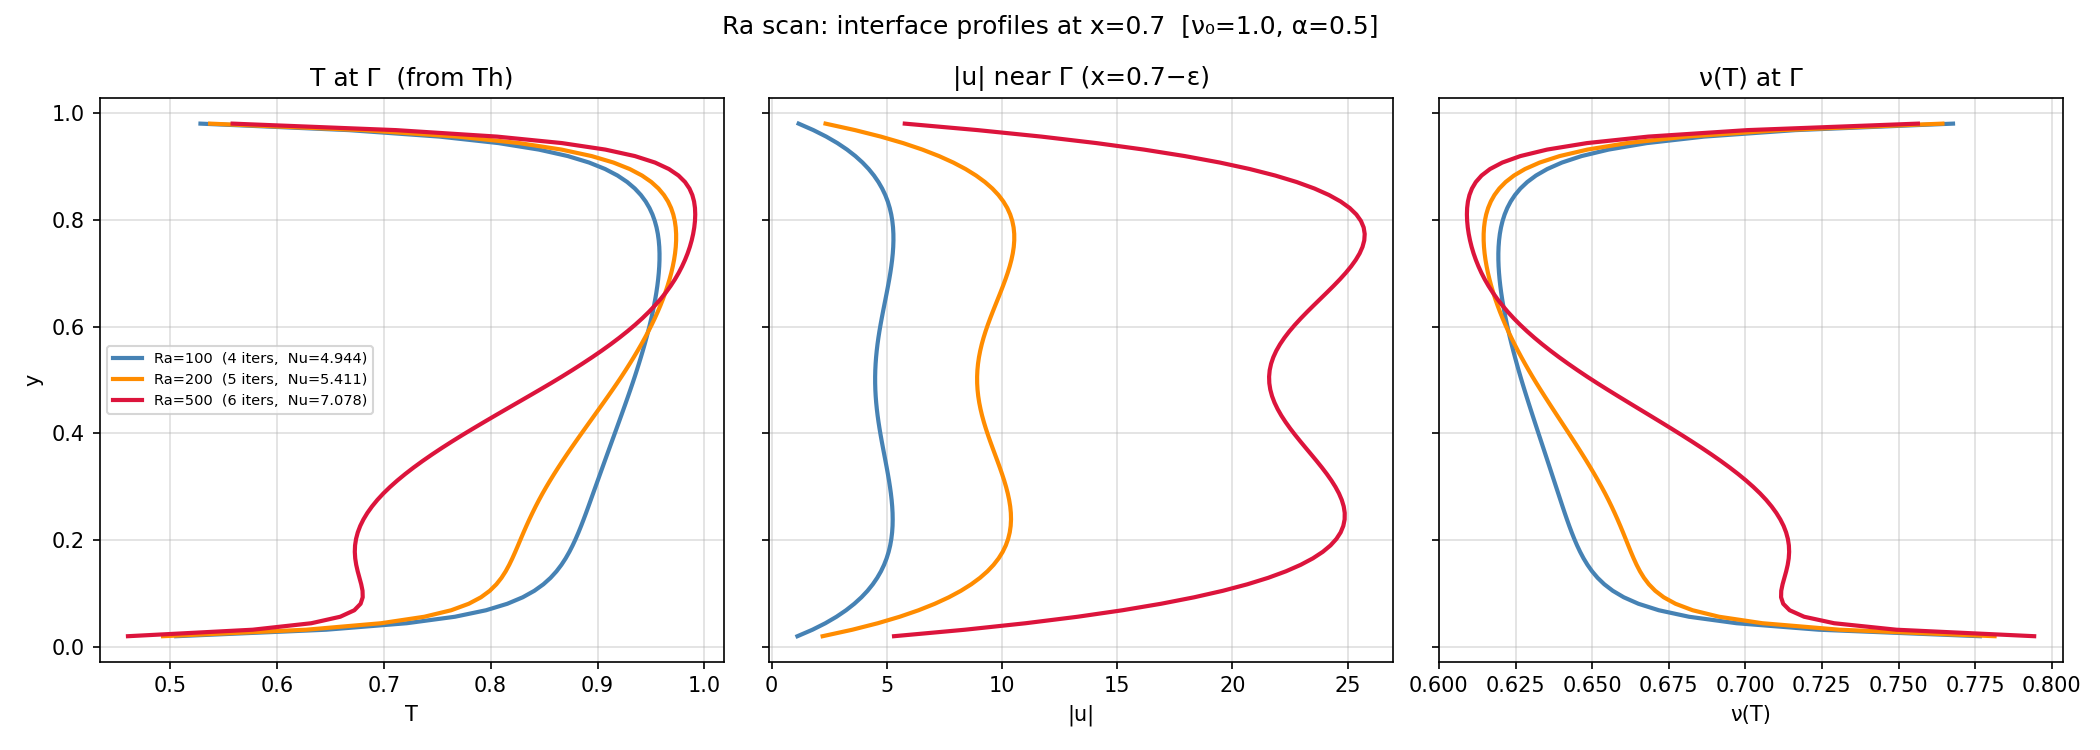

--- convergence_ra ---


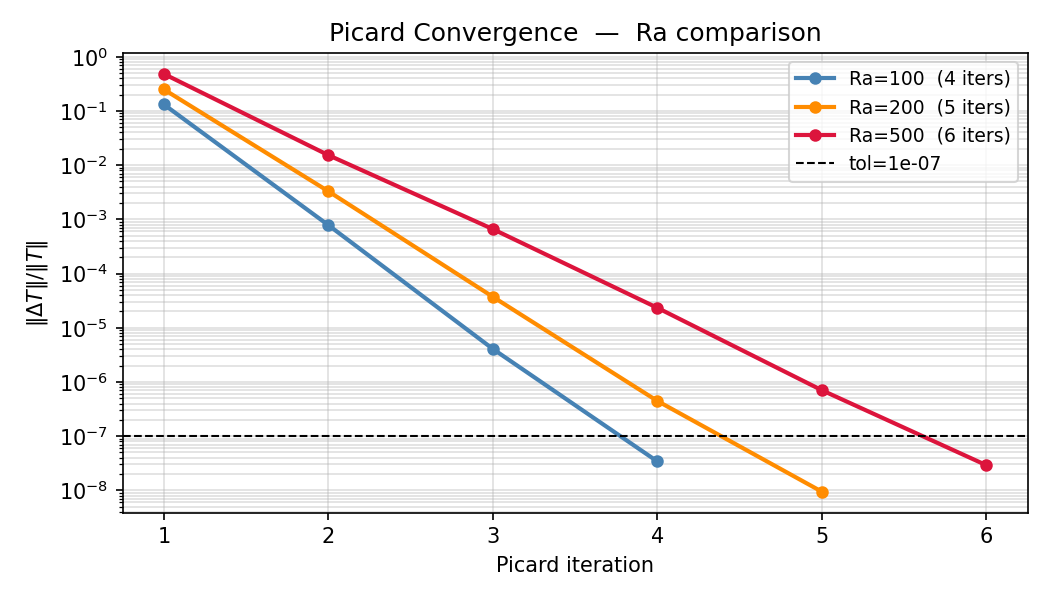

--- overlay ---


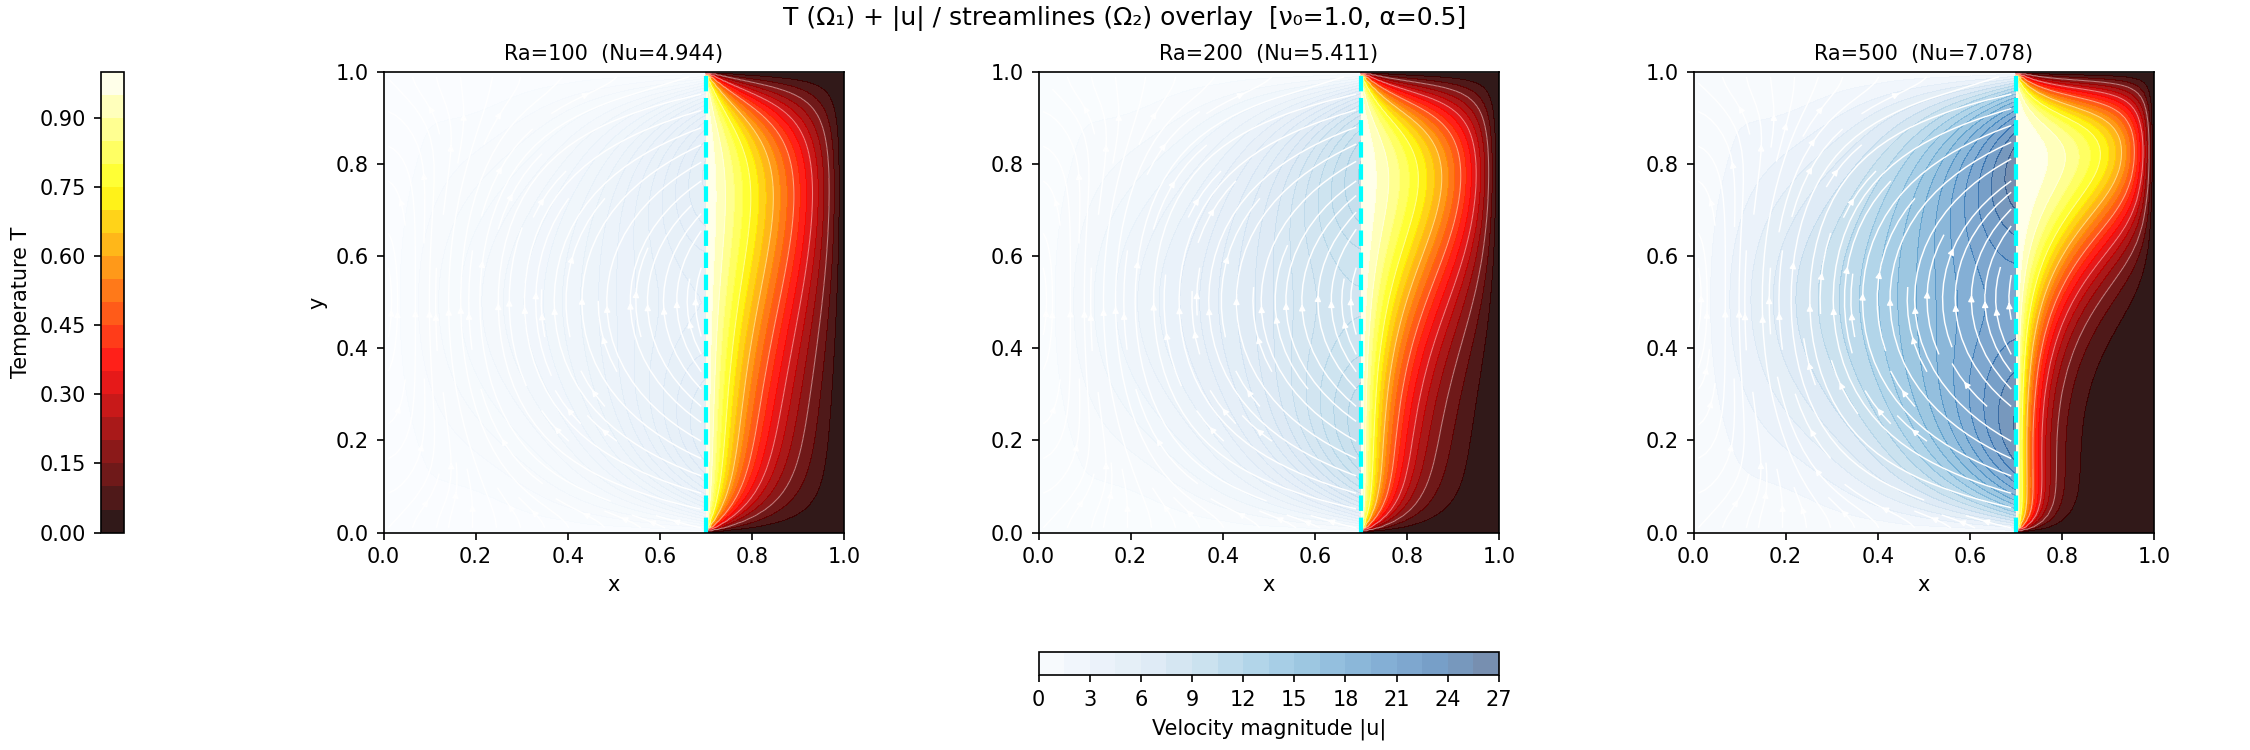

--- nusselt_vs_ra ---


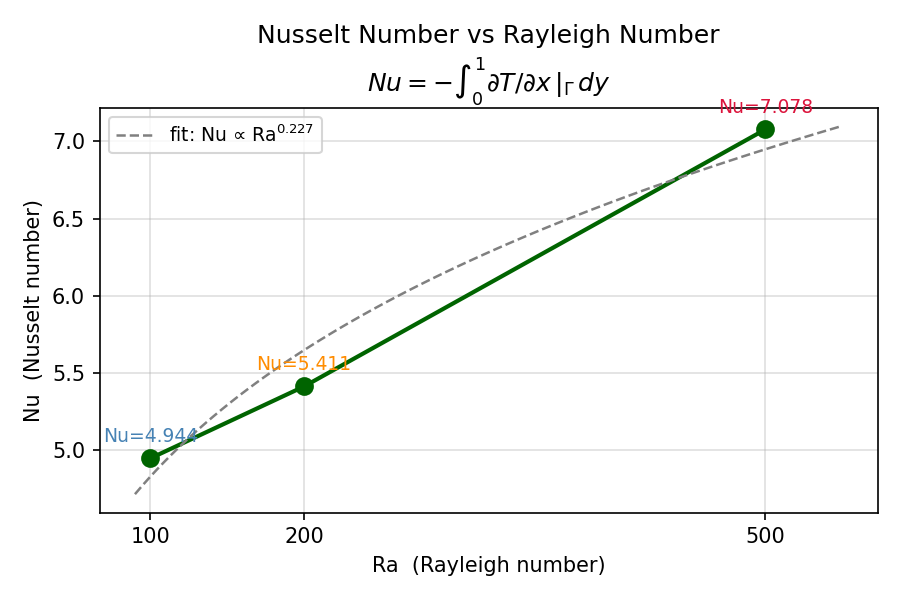

In [3]:
from IPython.display import Image, display
for f in ['convergence','fields','interface_profiles',
          'ra_scan','convergence_ra','overlay','nusselt_vs_ra']:
    print(f'--- {f} ---')
    display(Image(f'results/{f}.png'))